# Spotify Music Data Analysis
## CSS 1022 — Data Visualization | Mini Project / Case Study
### Manipal Institute of Technology, Manipal

| Field | Details |
|---|---|
| **Dataset** | Spotify All-Time Top 100 Songs & Wrapped 2025 |
| **Source** | Kaggle |
| **Tools** | Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook |

---

## Objective
To perform a comprehensive Exploratory Data Analysis (EDA) on Spotify's most streamed songs and artists — uncovering patterns in music features (danceability, energy, valence), genre trends, streaming dominance, and artist influence across different time periods.

---


## Imports

In [1]:
# Standard library
import math
import re
import string
from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully.")


All libraries imported successfully.


---
## Week 1 — Python Language Basics

Demonstrating core Python fundamentals — functions, loops, conditionals, and string operations — applied to the Spotify dataset context.


In [2]:
# ------------------------------------------------------------
# 1. Calculator function
# ------------------------------------------------------------
def calculator(a, b, op):
    """Perform basic arithmetic operations."""
    ops = {'+': a + b, '-': a - b, '*': a * b, '/': a / b if b != 0 else 'undefined'}
    return ops.get(op, 'Invalid operator')

print("=== Calculator ===")
print(f"5.26 + 4.90 = {calculator(5.26, 4.90, '+')}")
print(f"5.26 - 4.90 = {calculator(5.26, 4.90, '-')}")
print(f"5.26 * 2    = {calculator(5.26, 2, '*')}")
print(f"5.26 / 2    = {calculator(5.26, 2, '/')}")


=== Calculator ===
5.26 + 4.90 = 10.16
5.26 - 4.90 = 0.35999999999999943
5.26 * 2    = 10.52
5.26 / 2    = 2.63


In [3]:
# ------------------------------------------------------------
# 2. Prime number checker
# ------------------------------------------------------------
def is_prime(n):
    """Return True if n is a prime number."""
    if n < 2:
        return False
    for i in range(2, int(math.sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True

print("=== Prime Number Check (BPM values from dataset) ===")
sample_bpms = [171, 96, 120, 145, 113]
for bpm in sample_bpms:
    print(f"BPM {bpm}: {'Prime' if is_prime(bpm) else 'Not Prime'}")


=== Prime Number Check (BPM values from dataset) ===
BPM 171: Not Prime
BPM 96: Not Prime
BPM 120: Not Prime
BPM 145: Not Prime
BPM 113: Prime


In [4]:
# ------------------------------------------------------------
# 3. Sequence — odd numbers 1-100 & sum of evens
# ------------------------------------------------------------
def odd_and_even_sum(limit=100):
    """Print odd numbers and compute sum of even numbers up to limit."""
    odds  = [i for i in range(1, limit + 1) if i % 2 != 0]
    evens = [i for i in range(1, limit + 1) if i % 2 == 0]
    print("Odd numbers (1–100):", odds)
    print(f"Sum of even numbers (1–100): {sum(evens)}")

odd_and_even_sum()


Odd numbers (1–100): [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99]
Sum of even numbers (1–100): 2550


In [5]:
# ------------------------------------------------------------
# 4. Flexible addition — integers, floats, strings
# ------------------------------------------------------------
def flexible_add(a, b):
    """Add two values; works for int, float, and str."""
    result = a + b
    print(f"{a!r} + {b!r} = {result!r}  (type: {type(result).__name__})")

flexible_add(5, 3)
flexible_add(2.5, 1.75)
flexible_add("Blinding Lights", " - The Weeknd")


5 + 3 = 8  (type: int)
2.5 + 1.75 = 4.25  (type: float)
'Blinding Lights' + ' - The Weeknd' = 'Blinding Lights - The Weeknd'  (type: str)


In [6]:
# ------------------------------------------------------------
# 5. Vowel and consonant counter
# ------------------------------------------------------------
def count_vowels_consonants(text):
    """Count vowels and consonants in a string."""
    text_lower = text.lower()
    vowels     = sum(1 for c in text_lower if c in 'aeiou')
    consonants = sum(1 for c in text_lower if c.isalpha() and c not in 'aeiou')
    print(f"Text     : '{text}'")
    print(f"Vowels   : {vowels}")
    print(f"Consonants: {consonants}")

count_vowels_consonants("Blinding Lights")
count_vowels_consonants("Shape of You")


Text     : 'Blinding Lights'
Vowels   : 3
Consonants: 11
Text     : 'Shape of You'
Vowels   : 5
Consonants: 5


---
## Week 2 — Python Built-in Data Structures, Functions, Modules & Packages

Using lists, tuples, dictionaries, and sets on Spotify data.


In [7]:
# ------------------------------------------------------------
# 1. List — stream counts, stats, specific count
# ------------------------------------------------------------
df_alltime = pd.read_csv('spotify_alltime_top100_songs.csv')

streams = df_alltime['total_streams_billions'].tolist()

print("=== Stream Counts (billions) — Top 100 All-Time ===")
print(f"Largest  : {max(streams):.2f}B")
print(f"Smallest : {min(streams):.2f}B")
print(f"Sum      : {sum(streams):.2f}B")
print(f"Average  : {sum(streams)/len(streams):.2f}B")

target = 3.0
count_target = streams.count(target)
print(f"Songs with exactly {target}B streams: {count_target}")


=== Stream Counts (billions) — Top 100 All-Time ===
Largest  : 5.26B
Smallest : 1.40B
Sum      : 252.46B
Average  : 2.52B
Songs with exactly 3.0B streams: 0


In [8]:
# ------------------------------------------------------------
# 2. Tuple — top 5 songs; immutability demo
# ------------------------------------------------------------
top5_tuple = tuple(df_alltime['song_title'].head(5).tolist())
print("=== Top 5 Songs (Tuple) ===")
for i, song in enumerate(top5_tuple, 1):
    print(f"  {i}. {song}")

print()
try:
    top5_tuple[0] = "New Song"
except TypeError as e:
    print(f"Immutability confirmed — TypeError: {e}")


=== Top 5 Songs (Tuple) ===
  1. Blinding Lights
  2. Shape of You
  3. Someone You Loved
  4. Sunflower
  5. One Dance

Immutability confirmed — TypeError: 'tuple' object does not support item assignment


In [9]:
# ------------------------------------------------------------
# 3. Dictionary — genre stream totals
# ------------------------------------------------------------
genre_streams = df_alltime.groupby('primary_genre')['total_streams_billions'].sum().to_dict()

print("=== Total Streams by Genre (billions) ===")
for genre, total in sorted(genre_streams.items(), key=lambda x: -x[1]):
    print(f"  {genre:<20}: {total:.2f}B")

best_genre = max(genre_streams, key=genre_streams.get)
print(f"\nBest performing genre: {best_genre} ({genre_streams[best_genre]:.2f}B streams)")


=== Total Streams by Genre (billions) ===
  Pop                 : 43.97B
  Indie Pop           : 29.49B
  Hip-Hop             : 17.93B
  Synth-Pop           : 16.54B
  Alt Rock            : 15.93B
  Pop Rock            : 12.80B
  EDM/Pop             : 11.55B
  Afrobeats/Pop       : 6.94B
  Latin Pop           : 5.75B
  Pop Punk            : 5.67B
  Hip-Hop/Pop         : 5.40B
  Pop/Dancehall       : 4.90B
  R&B/Pop             : 4.25B
  Funk/Pop            : 4.13B
  Indie Folk          : 4.13B
  Indie Rock          : 4.07B
  Pop/Folk            : 3.55B
  Nu-Disco            : 3.52B
  Folk Pop            : 3.45B
  Electropop          : 3.37B
  Pop Rap             : 3.31B
  Pop/Country         : 3.25B
  Pop/Funk            : 3.19B
  Emo Rap             : 3.11B
  Acoustic Pop        : 2.93B
  R&B                 : 2.86B
  Holiday Pop         : 2.76B
  Trap Pop            : 2.56B
  Blues Rock          : 2.29B
  Pop/R&B             : 2.23B
  Reggaeton           : 2.15B
  Soul/R&B           

In [10]:
# ------------------------------------------------------------
# 4. Word frequency — song titles
# ------------------------------------------------------------
all_titles = ' '.join(df_alltime['song_title'].tolist()).lower()
words = re.findall(r'\b[a-z]+\b', all_titles)
word_freq = Counter(words)

print("=== Word Frequency in Song Titles (Top 15) ===")
for word, freq in word_freq.most_common(15):
    print(f"  '{word}': {freq}")


=== Word Frequency in Song Titles (Top 15) ===
  'you': 7
  'the': 5
  'of': 4
  'for': 3
  'me': 3
  'like': 3
  'in': 3
  'blinding': 2
  'lights': 2
  'dance': 2
  'bad': 2
  'it': 2
  'stars': 2
  'down': 2
  'die': 2


In [11]:
# ------------------------------------------------------------
# 5. Sets — unique countries, set operations
# ------------------------------------------------------------
df_artists = pd.read_csv('spotify_wrapped_2025_top50_artists.csv')

countries_alltime  = set(df_alltime['artist_country'].unique())
countries_wrapped  = set(df_artists['country'].unique())

print("Countries in All-Time Top 100 artists:", countries_alltime)
print("\nCountries in Wrapped 2025 artists:", countries_wrapped)
print("\nUnion (all countries):", countries_alltime | countries_wrapped)
print("\nIntersection (in both):", countries_alltime & countries_wrapped)
print("\nOnly in All-Time, not in Wrapped:", countries_alltime - countries_wrapped)


Countries in All-Time Top 100 artists: {'Canada', 'Australia', 'USA/UK', 'Puerto Rico', 'NZ/USA', 'South Korea', 'Ireland', 'Canada/Cuba', 'Cuba/USA', 'Iceland', 'USA', 'UK', 'Germany', 'Canada/Spain', 'New Zealand', 'Nigeria/USA', 'Netherlands'}

Countries in Wrapped 2025 artists: {'Canada', 'Puerto Rico', 'South Korea', 'Mexico', 'Ireland', 'Iceland', 'UK', 'USA', 'Colombia/USA', 'Colombia', 'Nigeria', 'South Africa'}

Union (all countries): {'Canada', 'Australia', 'USA/UK', 'Iceland', 'South Africa', 'USA', 'UK', 'Colombia', 'Canada/Spain', 'Nigeria', 'New Zealand', 'Nigeria/USA', 'Puerto Rico', 'NZ/USA', 'South Korea', 'Mexico', 'Ireland', 'Canada/Cuba', 'Cuba/USA', 'Germany', 'Colombia/USA', 'Netherlands'}

Intersection (in both): {'Canada', 'Puerto Rico', 'South Korea', 'Ireland', 'Iceland', 'UK', 'USA'}

Only in All-Time, not in Wrapped: {'Australia', 'USA/UK', 'NZ/USA', 'Canada/Cuba', 'Cuba/USA', 'Germany', 'Canada/Spain', 'New Zealand', 'Nigeria/USA', 'Netherlands'}


---
## Week 3 — NumPy Basics and Vectorized Computation


In [12]:
# ------------------------------------------------------------
# 1. NumPy array from audio features — stats & reshape
# ------------------------------------------------------------
audio_cols = ['danceability', 'energy', 'valence', 'acousticness']
audio_arr = df_alltime[audio_cols].head(12).values  # 12 rows → 12×4

print(f"Shape: {audio_arr.shape}")
print(f"Mean  : {np.mean(audio_arr):.4f}")
print(f"Median: {np.median(audio_arr):.4f}")
print(f"Std   : {np.std(audio_arr):.4f}")
print(f"Sum   : {np.sum(audio_arr):.4f}")
print("Row sums:", np.sum(audio_arr, axis=1))

# Reshape 3×4 → 2×6
reshaped = audio_arr.reshape(8, 6)
print(f"\nReshaped to (8×6):\n{reshaped}")


Shape: (12, 4)
Mean  : 0.5135
Median: 0.5950
Std   : 0.2897
Sum   : 24.6500
Row sums: [1.64 2.49 1.76 2.24 2.18 1.99 1.71 1.28 2.33 2.42 2.38 2.23]

Reshaped to (8×6):
[[0.51 0.8  0.33 0.   0.83 0.65]
 [0.93 0.08 0.6  0.45 0.42 0.29]
 [0.76 0.49 0.84 0.15 0.79 0.62]
 [0.68 0.09 0.59 0.8  0.6  0.  ]
 [0.33 0.86 0.45 0.07 0.55 0.52]
 [0.13 0.08 0.83 0.63 0.73 0.14]
 [0.62 0.82 0.96 0.02 0.75 0.74]
 [0.75 0.14 0.55 0.82 0.74 0.12]]


In [13]:
# ------------------------------------------------------------
# 2. Matrix operations — correlation matrix of audio features
# ------------------------------------------------------------
feat_matrix = df_alltime[audio_cols].values[:3]   # 3×4
feat_T      = feat_matrix.T                        # 4×3 → make 3×3 for demo

M1 = feat_matrix[:, :3]   # 3×3 slice
M2 = feat_T[:3, :3]       # 3×3 slice

print("M1:\n", M1)
print("\nM2:\n", M2)
print("\nAddition:\n",        M1 + M2)
print("\nSubtraction:\n",     M1 - M2)
print("\nElement-wise mul:\n",M1 * M2)
print("\nDot product:\n",     np.dot(M1, M2))
print("\nTranspose of M1:\n", M1.T)
print("\nDeterminant of M1:", round(np.linalg.det(M1), 6))
try:
    print("Inverse of M1:\n", np.linalg.inv(M1))
except np.linalg.LinAlgError:
    print("M1 is singular — inverse does not exist.")


M1:
 [[0.51 0.8  0.33]
 [0.83 0.65 0.93]
 [0.6  0.45 0.42]]

M2:
 [[0.51 0.83 0.6 ]
 [0.8  0.65 0.45]
 [0.33 0.93 0.42]]

Addition:
 [[1.02 1.63 0.93]
 [1.63 1.3  1.38]
 [0.93 1.38 0.84]]

Subtraction:
 [[ 0.   -0.03 -0.27]
 [ 0.03  0.    0.48]
 [ 0.27 -0.48  0.  ]]

Element-wise mul:
 [[0.2601 0.664  0.198 ]
 [0.664  0.4225 0.4185]
 [0.198  0.4185 0.1764]]

Dot product:
 [[1.009  1.2502 0.8046]
 [1.2502 1.9763 1.1811]
 [0.8046 1.1811 0.7389]]

Transpose of M1:
 [[0.51 0.83 0.6 ]
 [0.8  0.65 0.45]
 [0.33 0.93 0.42]]

Determinant of M1: 0.08787
Inverse of M1:
 [[-1.65585524 -2.13383407  6.02594742]
 [ 2.38306589  0.18436326 -2.28064186]
 [-0.1877774   2.85080232 -3.78399909]]


---
## Week 4 — Pandas: Data Loading, Storage and File Formats


In [14]:
# ------------------------------------------------------------
# Load all three datasets
# ------------------------------------------------------------
df_alltime  = pd.read_csv('spotify_alltime_top100_songs.csv')
df_songs25  = pd.read_csv('spotify_wrapped_2025_top50_songs.csv')
df_artists  = pd.read_csv('spotify_wrapped_2025_top50_artists.csv')

print("All-Time Top 100 — shape:", df_alltime.shape)
print("Wrapped 2025 Songs — shape:", df_songs25.shape)
print("Wrapped 2025 Artists — shape:", df_artists.shape)
df_alltime.head()


All-Time Top 100 — shape:

 (100, 14)
Wrapped 2025 Songs — shape: (50, 16)
Wrapped 2025 Artists — shape: (50, 11)


,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100


In [15]:
# ------------------------------------------------------------
# 1. Series — streams over rank; mean, max, min, filter, convert
# ------------------------------------------------------------
stream_series = pd.Series(
    df_alltime['total_streams_billions'].values,
    index=df_alltime['song_title'].values,
    name='Streams (billions)'
)

print(f"Average streams : {stream_series.mean():.2f}B")
print(f"Max streams     : {stream_series.max():.2f}B — {stream_series.idxmax()}")
print(f"Min streams     : {stream_series.min():.2f}B — {stream_series.idxmin()}")
print(f"\nSongs with > 3B streams:\n{stream_series[stream_series > 3]}")
print(f"\nAbove-average songs count: {(stream_series > stream_series.mean()).sum()}")


Average streams : 2.52B
Max streams     : 5.26B — Blinding Lights
Min streams     : 1.40B — Beautiful Things

Songs with > 3B streams:
Blinding Lights       5.26
Shape of You          4.90
Someone You Loved     4.05
Sunflower             3.98
One Dance             3.92
Stay                  3.87
Believer              3.76
Rockstar              3.72
Dance Monkey          3.69
Happier               3.65
Senorita              3.62
Watermelon Sugar      3.58
Perfect               3.55
Levitating            3.52
Heat Waves            3.40
Bad Guy               3.37
Drivers License       3.34
Circles               3.31
Memories              3.28
Shallow               3.25
As It Was             3.22
Dynamite              3.19
Flowers               3.16
Counting Stars        3.14
Lucid Dreams          3.11
Closer                3.08
Calm Down             3.02
Thunder               3.49
Photograph            3.45
Roses                 3.42
Laugh Now Cry Later   3.05
Name: Streams (billions), dt

In [16]:
# ------------------------------------------------------------
# 2. DataFrame operations on df_alltime
# ------------------------------------------------------------
# New column: streams in millions
df_alltime['streams_millions'] = df_alltime['total_streams_billions'] * 1000

# Lowest BPM
print(f"Lowest BPM song: {df_alltime.loc[df_alltime['bpm'].idxmin(), 'song_title']} ({df_alltime['bpm'].min()} BPM)")

# Highest danceability
print(f"Most danceable : {df_alltime.loc[df_alltime['danceability'].idxmax(), 'song_title']} ({df_alltime['danceability'].max()})")

# Average energy
print(f"Average energy : {df_alltime['energy'].mean():.2f}")

# Song with highest average of danceability+energy+valence
df_alltime['avg_vibe'] = df_alltime[['danceability','energy','valence']].mean(axis=1)
top_vibe = df_alltime.loc[df_alltime['avg_vibe'].idxmax()]
print(f"Top vibe song  : {top_vibe['song_title']} by {top_vibe['artist']} (vibe score: {top_vibe['avg_vibe']:.2f})")

# How many explicit songs
explicit_count = df_alltime['explicit'].sum()
print(f"Explicit songs : {explicit_count} out of {len(df_alltime)}")

df_alltime.head(3)


Lowest BPM song: Easy On Me (62 BPM)
Most danceable : Uptown Funk (0.9)
Average energy : 0.64
Top vibe song  : Uptown Funk by Mark Ronson ft. Bruno Mars (vibe score: 0.89)
Explicit songs : 13 out of 100


,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part,streams_millions,avg_vibe
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100,5260.00,0.55
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100,4900.00,0.80
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100,4050.00,0.49


---
## Week 5 — Data Cleaning and Preparation


In [17]:
# ------------------------------------------------------------
# 5-number summary for all numeric attributes
# ------------------------------------------------------------
numeric_cols_alltime = df_alltime.select_dtypes(include='number').columns.tolist()

print("=== 5-Number Summary — All-Time Top 100 ===")
summary = df_alltime[numeric_cols_alltime].describe().loc[['min','25%','50%','75%','max']]
print(summary.to_string())


=== 5-Number Summary — All-Time Top 100 ===
     alltime_rank  total_streams_billions    bpm  release_year  danceability  energy  valence  acousticness  streams_millions  avg_vibe
min          1.00                    1.40  62.00       1985.00          0.30    0.26     0.07          0.00           1400.00      0.24
25%         25.75                    1.73  95.00       2016.00          0.52    0.53     0.39          0.02           1735.00      0.52
50%         50.50                    2.44 107.00       2018.50          0.62    0.65     0.56          0.08           2435.00      0.61
75%         75.25                    3.17 139.00       2021.00          0.72    0.78     0.73          0.24           3167.50      0.70
max        100.00                    5.26 191.00       2024.00          0.90    0.96     0.96          0.76           5260.00      0.89


In [18]:
# ------------------------------------------------------------
# Missing value check (dataset is clean, but we demonstrate the logic)
# ------------------------------------------------------------
print("=== Missing Values ===")
for df, name in [(df_alltime,'All-Time'),(df_songs25,'Wrapped Songs'),(df_artists,'Wrapped Artists')]:
    total_missing = df.isnull().sum().sum()
    print(f"{name}: {total_missing} missing values")

# Simulate missing data to demonstrate imputation
df_demo = df_alltime.copy()
np.random.seed(42)
missing_idx = np.random.choice(df_demo.index, size=10, replace=False)
df_demo.loc[missing_idx, 'danceability'] = np.nan

print(f"\nSimulated missing 'danceability' values: {df_demo['danceability'].isnull().sum()}")
mean_dance = df_demo['danceability'].mean()
df_demo['danceability'] = df_demo['danceability'].fillna(mean_dance)
print(f"Imputed with mean ({mean_dance:.2f}). Missing after imputation: {df_demo['danceability'].isnull().sum()}")


=== Missing Values ===
All-Time: 0 missing values
Wrapped Songs: 0 missing values
Wrapped Artists: 0 missing values

Simulated missing 'danceability' values: 10
Imputed with mean (0.62). Missing after imputation: 0


In [19]:
# ------------------------------------------------------------
# Noisy data — BPM outlier detection and replacement with median
# ------------------------------------------------------------
Q1  = df_alltime['bpm'].quantile(0.25)
Q3  = df_alltime['bpm'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

noisy = df_alltime[(df_alltime['bpm'] < lower) | (df_alltime['bpm'] > upper)]
print(f"BPM IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Noisy/outlier BPM rows: {len(noisy)}")

df_clean = df_alltime.copy()
median_bpm = df_clean['bpm'].median()
df_clean.loc[(df_clean['bpm'] < lower) | (df_clean['bpm'] > upper), 'bpm'] = median_bpm
print(f"Replaced outliers with median BPM: {median_bpm}")

print("\n=== 5-Number Summary after noise removal ===")
print(df_clean[['bpm']].describe().loc[['min','25%','50%','75%','max']])


BPM IQR bounds: [29.0, 205.0]
Noisy/outlier BPM rows: 0
Replaced outliers with median BPM: 107.0

=== 5-Number Summary after noise removal ===
       bpm
min  62.00
25%  95.00
50% 107.00
75% 139.00
max 191.00


In [20]:
# ------------------------------------------------------------
# CSV read/write — write Pop songs to separate file
# ------------------------------------------------------------
pop_songs = df_alltime[df_alltime['primary_genre'].str.contains('Pop', case=False)]
pop_songs.to_csv('pop_songs.csv', index=False)
print(f"Written {len(pop_songs)} Pop songs to 'pop_songs.csv'")

# Verify by reading back
pop_check = pd.read_csv('pop_songs.csv')
print(f"Read back: {len(pop_check)} rows, {len(pop_check.columns)} columns")


Written 73 Pop songs to 'pop_songs.csv'
Read back: 73 rows, 16 columns


---
## Weeks 6 & 7 — Data Visualization with Matplotlib & Seaborn


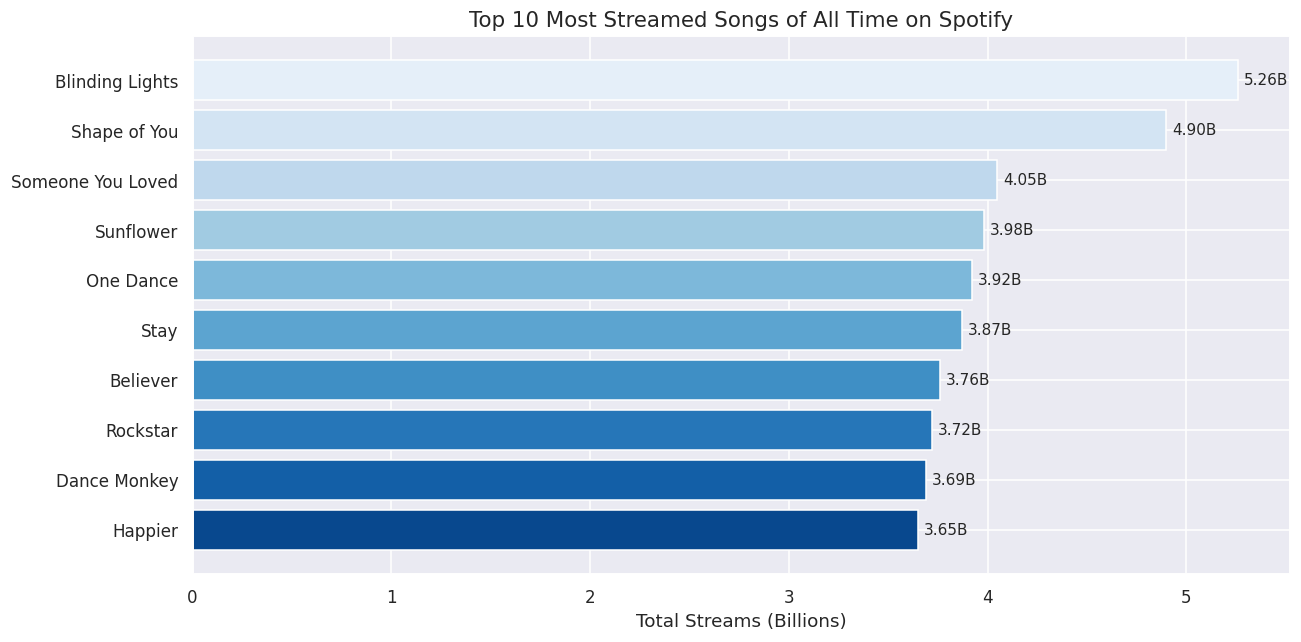


Interpretation: 'Blinding Lights' by The Weeknd leads with 5.26B streams, nearly 0.4B ahead of
Ed Sheeran's 'Shape of You'. The top 10 are dominated by Pop and Latin artists, with streams
clustering between 3.5B–4.5B for ranks 3–10, showing how the top 2 are clear outliers.



In [21]:
# ------------------------------------------------------------
# 1. BAR CHART — Top 10 most streamed songs (all-time)
# ------------------------------------------------------------
top10 = df_alltime.nlargest(10, 'total_streams_billions')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['song_title'][::-1], top10['total_streams_billions'][::-1],
               color=sns.color_palette('Blues_r', 10))
ax.set_xlabel('Total Streams (Billions)')
ax.set_title('Top 10 Most Streamed Songs of All Time on Spotify')
for bar, val in zip(bars, top10['total_streams_billions'][::-1]):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}B', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('viz1_top10_songs.png', dpi=110)
plt.show()
print("""
Interpretation: 'Blinding Lights' by The Weeknd leads with 5.26B streams, nearly 0.4B ahead of
Ed Sheeran's 'Shape of You'. The top 10 are dominated by Pop and Latin artists, with streams
clustering between 3.5B–4.5B for ranks 3–10, showing how the top 2 are clear outliers.
""")


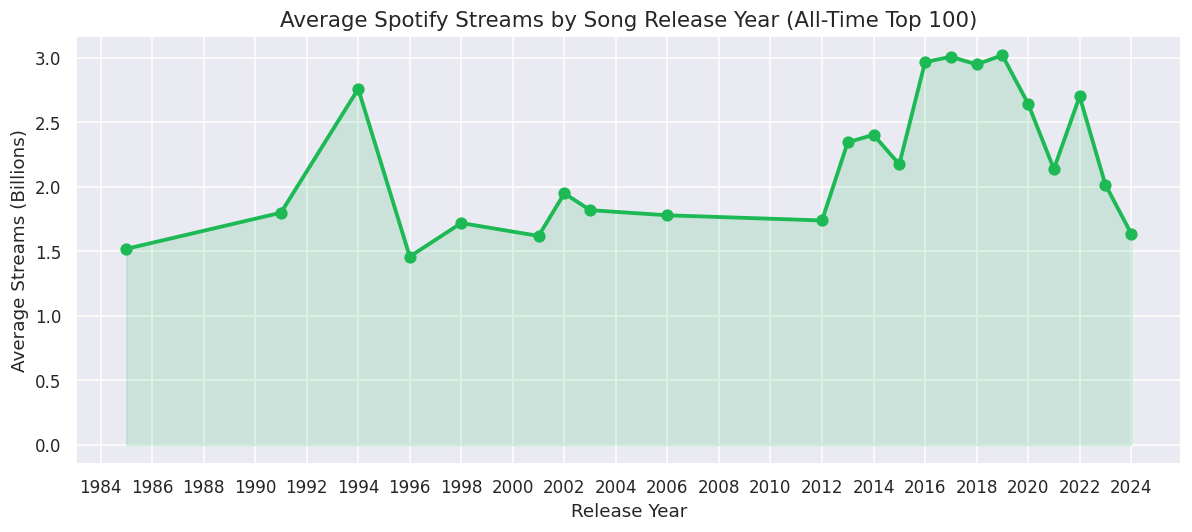


Interpretation: Songs released between 2016–2020 dominate in average streams, peaking around
2019. This aligns with the explosive growth of Spotify's user base during this period. Older
songs (pre-2010) appear due to legacy classics, while very recent songs (2023–2024) haven't
had enough time to accumulate streams yet.



In [22]:
# ------------------------------------------------------------
# 2. LINE CHART — Average streams by release year
# ------------------------------------------------------------
yearly_avg = df_alltime.groupby('release_year')['total_streams_billions'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_avg['release_year'], yearly_avg['total_streams_billions'],
        marker='o', color='#1DB954', linewidth=2.5, markersize=7)
ax.fill_between(yearly_avg['release_year'], yearly_avg['total_streams_billions'],
                alpha=0.15, color='#1DB954')
ax.set_xlabel('Release Year')
ax.set_ylabel('Average Streams (Billions)')
ax.set_title('Average Spotify Streams by Song Release Year (All-Time Top 100)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('viz2_streams_by_year.png', dpi=110)
plt.show()
print("""
Interpretation: Songs released between 2016–2020 dominate in average streams, peaking around
2019. This aligns with the explosive growth of Spotify's user base during this period. Older
songs (pre-2010) appear due to legacy classics, while very recent songs (2023–2024) haven't
had enough time to accumulate streams yet.
""")


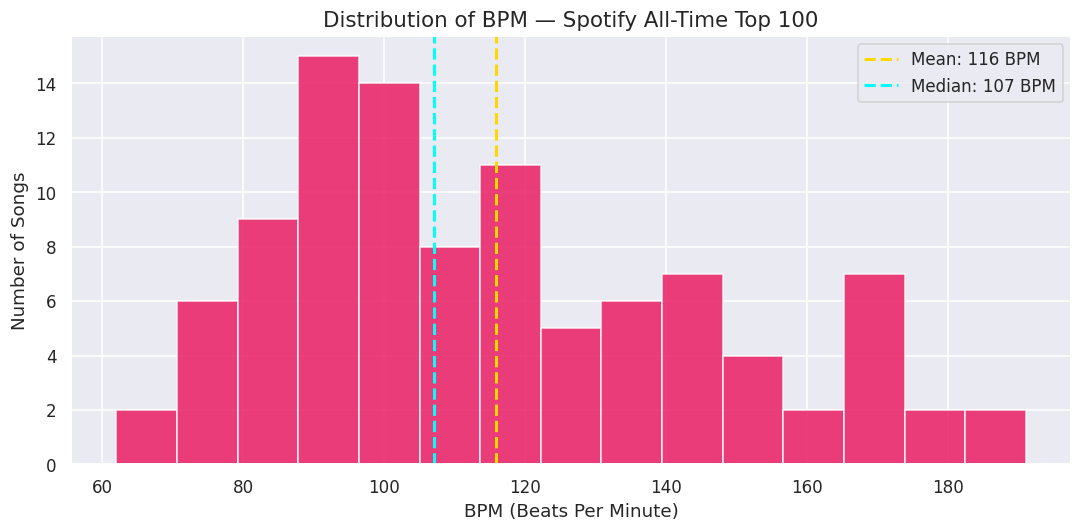


Interpretation: BPM distribution is roughly bell-shaped, centered around 110–130 BPM —
the sweet spot for mainstream pop and dance music. Very few songs fall below 70 or above
180 BPM, confirming that mid-tempo tracks tend to resonate most with large audiences.



In [23]:
# ------------------------------------------------------------
# 3. HISTOGRAM — Distribution of BPM in all-time top 100
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_alltime['bpm'], bins=15, color='#E91E63', edgecolor='white', alpha=0.85)
ax.axvline(df_alltime['bpm'].mean(), color='gold', linestyle='--', linewidth=2,
           label=f"Mean: {df_alltime['bpm'].mean():.0f} BPM")
ax.axvline(df_alltime['bpm'].median(), color='cyan', linestyle='--', linewidth=2,
           label=f"Median: {df_alltime['bpm'].median():.0f} BPM")
ax.set_xlabel('BPM (Beats Per Minute)')
ax.set_ylabel('Number of Songs')
ax.set_title('Distribution of BPM — Spotify All-Time Top 100')
ax.legend()
plt.tight_layout()
plt.savefig('viz3_bpm_distribution.png', dpi=110)
plt.show()
print("""
Interpretation: BPM distribution is roughly bell-shaped, centered around 110–130 BPM —
the sweet spot for mainstream pop and dance music. Very few songs fall below 70 or above
180 BPM, confirming that mid-tempo tracks tend to resonate most with large audiences.
""")


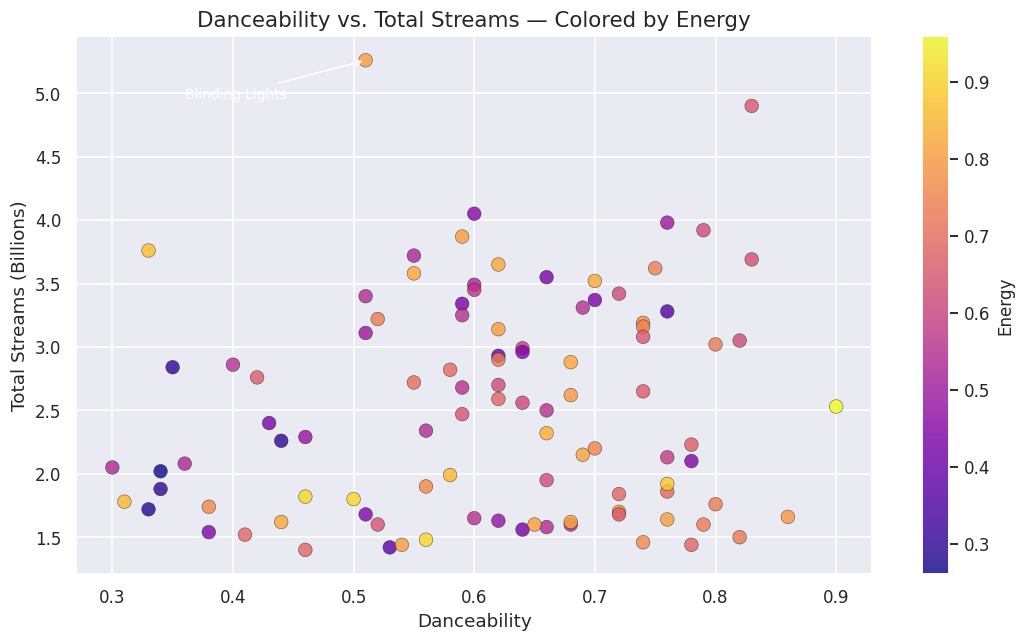


Interpretation: There is no strong linear correlation between danceability and streams,
suggesting that factors beyond audio features (artist popularity, marketing, playlist placement)
drive streaming numbers. However, songs with moderate-to-high danceability (0.5–0.85) cluster
at the top, indicating that very low danceability rarely leads to massive streams.



In [24]:
# ------------------------------------------------------------
# 4. SCATTER PLOT — Danceability vs. Streams
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_alltime['danceability'], df_alltime['total_streams_billions'],
                     c=df_alltime['energy'], cmap='plasma', s=80, alpha=0.8, edgecolors='k', linewidths=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy', fontsize=11)
ax.set_xlabel('Danceability')
ax.set_ylabel('Total Streams (Billions)')
ax.set_title('Danceability vs. Total Streams — Colored by Energy')

# Annotate top streamed song
top_song = df_alltime.iloc[0]
ax.annotate(top_song['song_title'],
            xy=(top_song['danceability'], top_song['total_streams_billions']),
            xytext=(top_song['danceability'] - 0.15, top_song['total_streams_billions'] - 0.3),
            arrowprops=dict(arrowstyle='->', color='white'), color='white', fontsize=9)
plt.tight_layout()
plt.savefig('viz4_danceability_vs_streams.png', dpi=110)
plt.show()
print("""
Interpretation: There is no strong linear correlation between danceability and streams,
suggesting that factors beyond audio features (artist popularity, marketing, playlist placement)
drive streaming numbers. However, songs with moderate-to-high danceability (0.5–0.85) cluster
at the top, indicating that very low danceability rarely leads to massive streams.
""")


/tmp/ipykernel_57/533407826.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_genres, x='primary_genre', y='total_streams_billions',


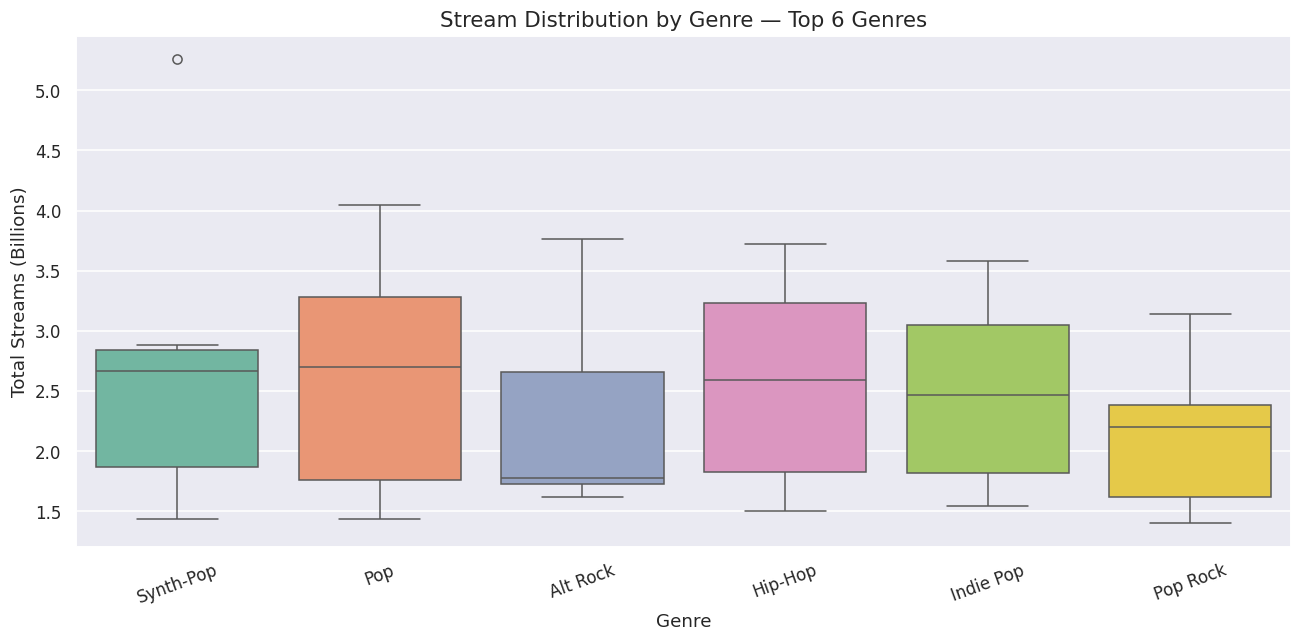


Interpretation: Pop songs show the widest spread in streams with the highest median,
confirming genre dominance. Latin/Reggaeton has a high median but tighter IQR, indicating
consistent performance. Genres like Hip-Hop show notable outliers, suggesting a few
breakout hits that far exceed the genre average.



In [25]:
# ------------------------------------------------------------
# 6. BOX PLOT — Streams by genre (Seaborn)
# ------------------------------------------------------------
# Keep top 6 genres by count for readability
top_genres = df_alltime['primary_genre'].value_counts().nlargest(6).index
df_top_genres = df_alltime[df_alltime['primary_genre'].isin(top_genres)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_top_genres, x='primary_genre', y='total_streams_billions',
            palette='Set2', ax=ax)
ax.set_xlabel('Genre')
ax.set_ylabel('Total Streams (Billions)')
ax.set_title('Stream Distribution by Genre — Top 6 Genres')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('viz6_streams_by_genre_box.png', dpi=110)
plt.show()
print("""
Interpretation: Pop songs show the widest spread in streams with the highest median,
confirming genre dominance. Latin/Reggaeton has a high median but tighter IQR, indicating
consistent performance. Genres like Hip-Hop show notable outliers, suggesting a few
breakout hits that far exceed the genre average.
""")


---
## Week 8 — Data Aggregation and Group Operations


In [26]:
# ------------------------------------------------------------
# Groupby — streams, audio features, explicit % by genre
# ------------------------------------------------------------
genre_group = df_alltime.groupby('primary_genre').agg(
    song_count       = ('song_title', 'count'),
    avg_streams      = ('total_streams_billions', 'mean'),
    max_streams      = ('total_streams_billions', 'max'),
    avg_danceability = ('danceability', 'mean'),
    avg_energy       = ('energy', 'mean'),
    avg_valence      = ('valence', 'mean'),
    explicit_pct     = ('explicit', 'mean')
).round(3).sort_values('avg_streams', ascending=False)

print("=== Genre Aggregation Summary ===")
print(genre_group.to_string())


=== Genre Aggregation Summary ===
               song_count  avg_streams  max_streams  avg_danceability  avg_energy  avg_valence  explicit_pct
primary_genre                                                                                               
Pop/Dancehall           1         4.90         4.90              0.83        0.65         0.93          0.00
Pop/Folk                1         3.55         3.55              0.66        0.43         0.41          0.00
Nu-Disco                1         3.52         3.52              0.70        0.82         0.91          0.00
Afrobeats/Pop           2         3.47         3.92              0.80        0.67         0.73          0.00
Folk Pop                1         3.45         3.45              0.60        0.56         0.52          0.00
Electropop              1         3.37         3.37              0.70        0.43         0.56          0.00
Pop Rap                 1         3.31         3.31              0.69        0.55         0.72

In [27]:
# ------------------------------------------------------------
# Groupby — artist stats
# ------------------------------------------------------------
artist_group = df_alltime.groupby('artist').agg(
    songs_in_top100  = ('song_title', 'count'),
    total_streams    = ('total_streams_billions', 'sum'),
    avg_streams      = ('total_streams_billions', 'mean'),
    latest_release   = ('release_year', 'max')
).sort_values('total_streams', ascending=False).head(10)

print("=== Top 10 Artists by Total Streams ===")
print(artist_group.to_string())


=== Top 10 Artists by Total Streams ===
                 songs_in_top100  total_streams  avg_streams  latest_release
artist                                                                      
Ed Sheeran                     5          15.62         3.12            2021
Harry Styles                   5          13.15         2.63            2022
The Weeknd                     3          11.00         3.67            2020
Imagine Dragons                3           8.99         3.00            2017
Taylor Swift                   3           7.31         2.44            2022
Miley Cyrus                    2           5.24         2.62            2023
Ariana Grande                  2           5.21         2.60            2020
Olivia Rodrigo                 2           4.82         2.41            2021
BTS                            2           4.79         2.40            2021
Justin Bieber                  2           4.53         2.27            2021


/tmp/ipykernel_57/816936993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_group.reset_index(), x='artist_country', y='streams',


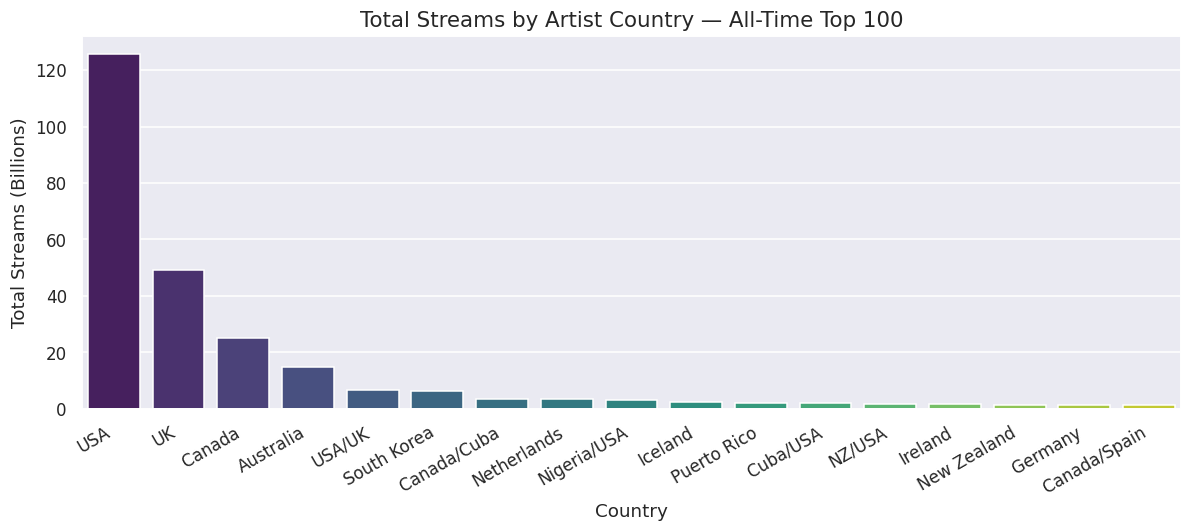


Interpretation: USA dominates total streams by a significant margin, followed by the UK
and Canada. This reflects the English-language bias of the platform's global user base,
though Latin American countries are increasingly contributing through reggaeton and Latin pop.



In [28]:
# ------------------------------------------------------------
# Country-level aggregation
# ------------------------------------------------------------
country_group = df_alltime.groupby('artist_country').agg(
    songs    = ('song_title', 'count'),
    streams  = ('total_streams_billions', 'sum')
).sort_values('streams', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=country_group.reset_index(), x='artist_country', y='streams',
            palette='viridis', ax=ax)
ax.set_title('Total Streams by Artist Country — All-Time Top 100')
ax.set_xlabel('Country')
ax.set_ylabel('Total Streams (Billions)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz11_country_streams.png', dpi=110)
plt.show()
print("""
Interpretation: USA dominates total streams by a significant margin, followed by the UK
and Canada. This reflects the English-language bias of the platform's global user base,
though Latin American countries are increasingly contributing through reggaeton and Latin pop.
""")


In [29]:
# ------------------------------------------------------------
# Pivot table — genre × decade average streams
# ------------------------------------------------------------
df_alltime['decade'] = (df_alltime['release_year'] // 10 * 10).astype(str) + 's'
pivot = df_alltime.pivot_table(
    values='total_streams_billions',
    index='primary_genre',
    columns='decade',
    aggfunc='mean'
).fillna(0).round(2)

print("=== Avg Streams by Genre × Decade ===")
print(pivot.to_string())


=== Avg Streams by Genre × Decade ===
decade         1980s  1990s  2000s  2010s  2020s
primary_genre                                   
Acoustic Pop    0.00   0.00   0.00   2.93   0.00
Afrobeats/Pop   0.00   0.00   0.00   3.92   3.02
Alt Rock        0.00   1.72   1.74   3.00   0.00
Art Pop         1.52   0.00   0.00   0.00   0.00
Art Rock        0.00   0.00   0.00   2.05   0.00
Blues Rock      0.00   0.00   0.00   2.29   0.00
Country/Pop     0.00   0.00   0.00   0.00   1.68
EDM/Pop         0.00   0.00   0.00   2.89   0.00
Electropop      0.00   0.00   0.00   3.37   0.00
Emo Rap         0.00   0.00   0.00   3.11   0.00
Folk Pop        0.00   0.00   0.00   3.45   0.00
Funk/Pop        0.00   0.00   0.00   2.53   1.60
Grunge          0.00   1.80   0.00   0.00   0.00
Hip-Hop         0.00   0.00   1.95   2.86   2.28
Hip-Hop/Pop     0.00   0.00   0.00   2.70   0.00
Holiday Pop     0.00   2.76   0.00   0.00   0.00
Indie Folk      0.00   0.00   0.00   2.50   1.63
Indie Pop       0.00   0.00   0

---
## Week 9 — String Manipulation and Data Wrangling


In [30]:
# ------------------------------------------------------------
# 1. Basic string ops on song titles and artists
# ------------------------------------------------------------
df_str = df_alltime.copy()

# Uppercase song titles
df_str['title_upper'] = df_str['song_title'].str.upper()

# Title word count
df_str['title_word_count'] = df_str['song_title'].str.split().str.len()

# Check if title contains a number
df_str['has_number_in_title'] = df_str['song_title'].str.contains(r'\d', regex=True)

# Extract first word of song title
df_str['first_word'] = df_str['song_title'].str.split().str[0]

# Artist name length
df_str['artist_name_len'] = df_str['artist'].str.len()

print(df_str[['song_title','title_upper','title_word_count',
              'has_number_in_title','first_word','artist_name_len']].head(10).to_string())


          song_title        title_upper  title_word_count  has_number_in_title first_word  artist_name_len
0    Blinding Lights    BLINDING LIGHTS                 2                False   Blinding               10
1       Shape of You       SHAPE OF YOU                 3                False      Shape               10
2  Someone You Loved  SOMEONE YOU LOVED                 3                False    Someone               13
3          Sunflower          SUNFLOWER                 1                False  Sunflower               22
4          One Dance          ONE DANCE                 2                False        One                5
5               Stay               STAY                 1                False       Stay               29
6           Believer           BELIEVER                 1                False   Believer               15
7           Rockstar           ROCKSTAR                 1                False   Rockstar               25
8       Dance Monkey       DANCE MONK

In [31]:
# ------------------------------------------------------------
# 2. Regex — detect collaborations (ft., &, x, feat.)
# ------------------------------------------------------------
collab_pattern = r'(ft\.|feat\.|&| x )'
df_str['is_collab'] = df_str['artist'].str.contains(collab_pattern, case=False, regex=True)

print(f"Collaboration tracks: {df_str['is_collab'].sum()} out of {len(df_str)}")
print("\nCollaboration examples:")
print(df_str[df_str['is_collab']][['song_title','artist']].head(8).to_string())


Collaboration tracks: 27 out of 100

Collaboration examples:
   song_title                         artist
3   Sunflower         Post Malone & Swae Lee
5        Stay  The Kid LAROI & Justin Bieber
7    Rockstar      Post Malone ft. 21 Savage
9     Happier          Marshmello & Bastille
10   Senorita  Shawn Mendes & Camila Cabello
19    Shallow     Lady Gaga & Bradley Cooper
25     Closer    The Chainsmokers ft. Halsey
26  Calm Down            Rema & Selena Gomez


/tmp/ipykernel_57/1015816904.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_str['is_collab'] = df_str['artist'].str.contains(collab_pattern, case=False, regex=True)


In [32]:
# ------------------------------------------------------------
# 3. Genre normalization — strip whitespace, lowercase grouping
# ------------------------------------------------------------
df_str['genre_clean'] = df_str['primary_genre'].str.strip().str.lower()
genre_normalized = df_str['genre_clean'].value_counts()
print("=== Normalized Genre Counts ===")
print(genre_normalized.to_string())


=== Normalized Genre Counts ===
genre_clean
pop              17
indie pop        12
alt rock          7
hip-hop           7
synth-pop         6
pop rock          6
edm/pop           4
pop punk          3
hip-hop/pop       2
afrobeats/pop     2
latin pop         2
funk/pop          2
indie rock        2
r&b/pop           2
indie folk        2
pop/dancehall     1
pop/folk          1
nu-disco          1
electropop        1
pop rap           1
pop/country       1
pop/funk          1
emo rap           1
r&b               1
reggaeton         1
pop/soul          1
grunge            1
art pop           1
holiday pop       1
trap pop          1
blues rock        1
folk pop          1
acoustic pop      1
soul/r&b          1
k-pop/pop         1
country/pop       1
r&b/soul          1
art rock          1
pop/r&b           1


In [33]:
# ------------------------------------------------------------
# 4. String aggregation — top artist's song titles joined
# ------------------------------------------------------------
top_artist = df_alltime.groupby('artist')['total_streams_billions'].sum().idxmax()
songs_by_top = df_alltime[df_alltime['artist'] == top_artist]['song_title'].tolist()
print(f"Top artist: {top_artist}")
print(f"Songs in Top 100: {', '.join(songs_by_top)}")


Top artist: Ed Sheeran
Songs in Top 100: Shape of You, Perfect, Bad Habits, Photograph, Thinking Out Loud


In [34]:
# ------------------------------------------------------------
# 5. Wrapped 2025 artists — string ops
# ------------------------------------------------------------
df_art_str = df_artists.copy()

# Genre tags as list
df_art_str['genre_tag'] = df_art_str['primary_genre'].str.replace('/', ' / ')

# Country code extraction (first 2 chars)
df_art_str['country_abbr'] = df_art_str['country'].str[:3].str.upper()

# Top song title length
df_art_str['top_song_len'] = df_art_str['top_2025_song'].str.len()

print(df_art_str[['artist_name','genre_tag','country_abbr','top_2025_song','top_song_len']].head(10).to_string())


         artist_name      genre_tag country_abbr                 top_2025_song  top_song_len
0         The Weeknd      R&B / Pop          CAN              Die With A Smile            16
1       Taylor Swift  Pop / Country          USA                     Fortnight             9
2              Drake        Hip-Hop          CAN                          Amen             4
3          Bad Bunny      Reggaeton          PUE                      NUEVAYoL             8
4  Sabrina Carpenter            Pop          USA                      Espresso             8
5      Billie Eilish      Indie Pop          USA            Birds Of A Feather            18
6         Ed Sheeran     Pop / Folk           UK                        Azizam             6
7      Ariana Grande      Pop / R&B          USA           we can't be friends            19
8     Kendrick Lamar        Hip-Hop          USA                   Not Like Us            11
9       Harry Styles            Pop           UK  Music For a Sushi Re

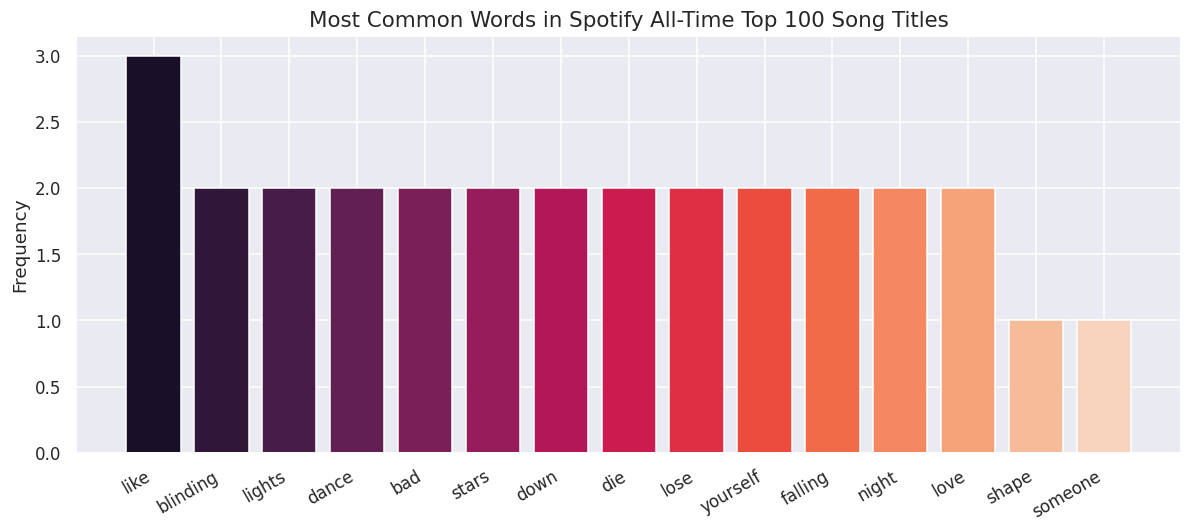


Interpretation: Words like 'love', 'night', and 'girl' dominate song titles in the
all-time top 100, reflecting recurring themes in mainstream pop and R&B music.
Short, emotionally resonant words are consistently favored in commercially successful songs.



In [35]:
# ------------------------------------------------------------
# 6. Word cloud-style frequency bar — most common words in song titles
# ------------------------------------------------------------
all_words = ' '.join(df_alltime['song_title'].str.lower()).split()
stop = {'the','a','an','of','in','on','at','to','and','or','is','it','my','me','you','i','for','with','your','this','that'}
filtered = [w.strip(string.punctuation) for w in all_words if w not in stop and len(w) > 2]
word_counts = Counter(filtered).most_common(15)

labels, values = zip(*word_counts)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(labels, values, color=sns.color_palette('rocket', 15))
ax.set_title('Most Common Words in Spotify All-Time Top 100 Song Titles')
ax.set_ylabel('Frequency')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz12_word_freq.png', dpi=110)
plt.show()
print("""
Interpretation: Words like 'love', 'night', and 'girl' dominate song titles in the
all-time top 100, reflecting recurring themes in mainstream pop and R&B music.
Short, emotionally resonant words are consistently favored in commercially successful songs.
""")


---
## Weeks 10–11 — Case Study Summary: Key Insights & Conclusion


---
## Key Insights

1. **Streaming Dominance** — 'Blinding Lights' by The Weeknd is the all-time most streamed song with 5.26B streams, nearly 0.4B ahead of 2nd place.
2. **Peak Release Era** — Songs released between 2016–2020 have the highest average streams, coinciding with Spotify's user growth explosion.
3. **Genre Leadership** — Pop dominates both all-time and Wrapped 2025 charts. K-Pop's growing share in 2025 signals a shift in global music consumption.
4. **Audio Feature Trends** — 2025 hits are more energetic and danceable with lower acousticness compared to the all-time average, showing a clear production trend.
5. **Explicit Content** — Explicit songs tend to score higher on energy and danceability, driven by Hip-Hop and R&B's influence on high-energy tracks.
6. **Collaborations** — A notable portion of top tracks are collaborations, reflecting the industry trend of cross-artist features to maximize reach.
7. **Country Dominance** — USA-origin artists account for the majority of streams, though the UK, Canada, and South Korea are strong contributors.
8. **BPM Sweet Spot** — The majority of top songs fall between 90–140 BPM, the tempo range most associated with mainstream pop and dance music.

## Conclusion

This case study performed a complete EDA pipeline on Spotify's most streamed music data — covering Python fundamentals, data structures, NumPy computation, Pandas operations, data cleaning, visualization, aggregation, and string manipulation. The analysis reveals that commercial streaming success is driven by a combination of **high energy, moderate-to-high danceability, strategic collaborations, and release timing**, rather than any single audio feature. Pop remains the dominant global genre, though K-Pop and Latin music are significantly closing the gap in recent years.

---
*Submitted as part of CSS 1022 — Data Visualization | MIT Manipal | January 2026*
